In [1]:
!git clone --depth=1 https://github.com/microsoft/FERPlus.git /content/FERPlus

fatal: destination path '/content/FERPlus' already exists and is not an empty directory.


✅ Downloads complete
  FER-2013 CSV: True
  FER+ CSV    : True
FER-2013 rows : 35,887
FER+     rows : 35,887

✅ Images generated:
  Training       : 28,561
  PublicTest     : 3,579
  PrivateTest    : 3,574
  Skipped: 173
  FER+ DIAGNOSTIC SUMMARY
  Total CSV rows (after dropna)   : 35,714
  Non-face (NF > 50%)             : 3
  Contempt majority               : 221
  Usable 7-class                  : 35,490
  High-confidence (≥0.8)          : 19,475 (54.9%)
  Ambiguous (<0.5 conf)           : 2,394 (6.7%)
  Mean entropy                    : 0.718 bits
  Low entropy  (<1.0 bit)         : 26,248
  High entropy (>2.0 bits)        : 479
  Training       : 28,392 / 28,561 usable
  PublicTest     : 3,554 / 3,579 usable
  PrivateTest    : 3,544 / 3,574 usable


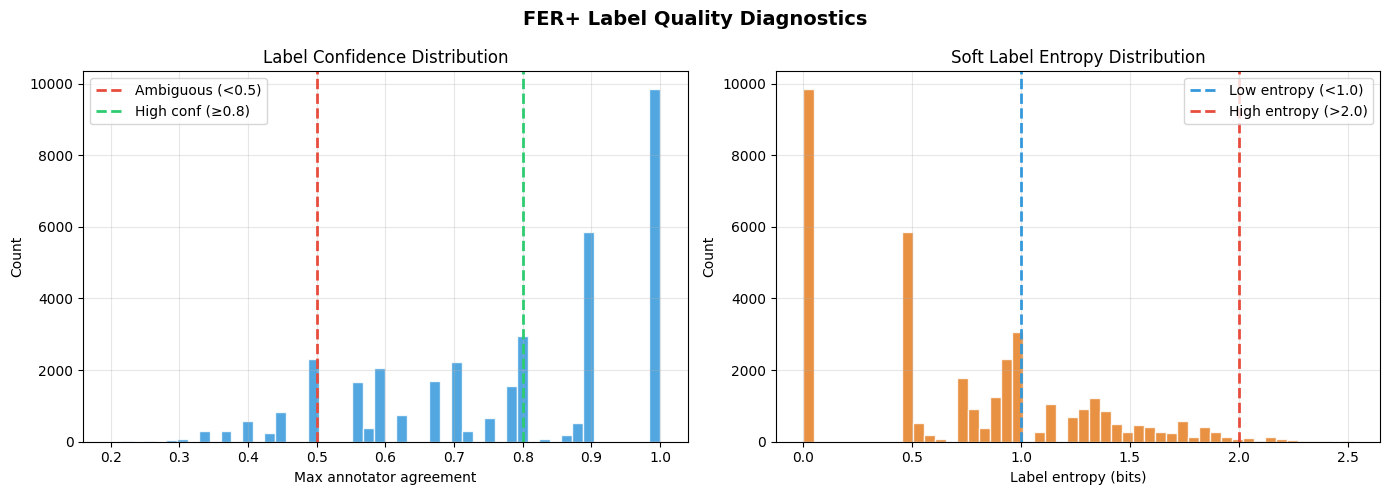

Saved: ferplus_label_diagnostics.png
Device: cuda
Building FER+ datasets...
[Training    ] 28,392 samples | avg entropy: 0.730 bits
[PublicTest  ]  3,554 samples | avg entropy: 0.651 bits
[PrivateTest ]  3,544 samples | avg entropy: 0.696 bits

Split summary:
  Train : 28,392  (Training split)
  Val   : 3,554  (PublicTest split)
  Test  : 3,544  (PrivateTest split — untouched until final eval)

Batch check: images=torch.Size([128, 1, 48, 48])  soft=torch.Size([128, 7])  sum=1.000

MLP wider_deeper (FER+) | Parameters: 7,484,423
Config: lr=0.001  wd=5e-05  max_ep=120  warmup=5  patience=20

  Ep          LR   Tr Loss   Tr Acc   Va Loss   Va Acc
──────────────────────────────────────────────────────────────
   1    3.60e-04    1.6067   42.34%    1.4691   49.97% ★
   2    5.20e-04    1.5066   48.15%    1.4219   51.94% ★
   3    6.80e-04    1.4643   50.08%    1.4022   53.60% ★
   4    8.40e-04    1.4370   51.57%    1.3751   53.63% ★
   5    1.00e-03    1.4193   52.11%    1.3623   54.59% ★


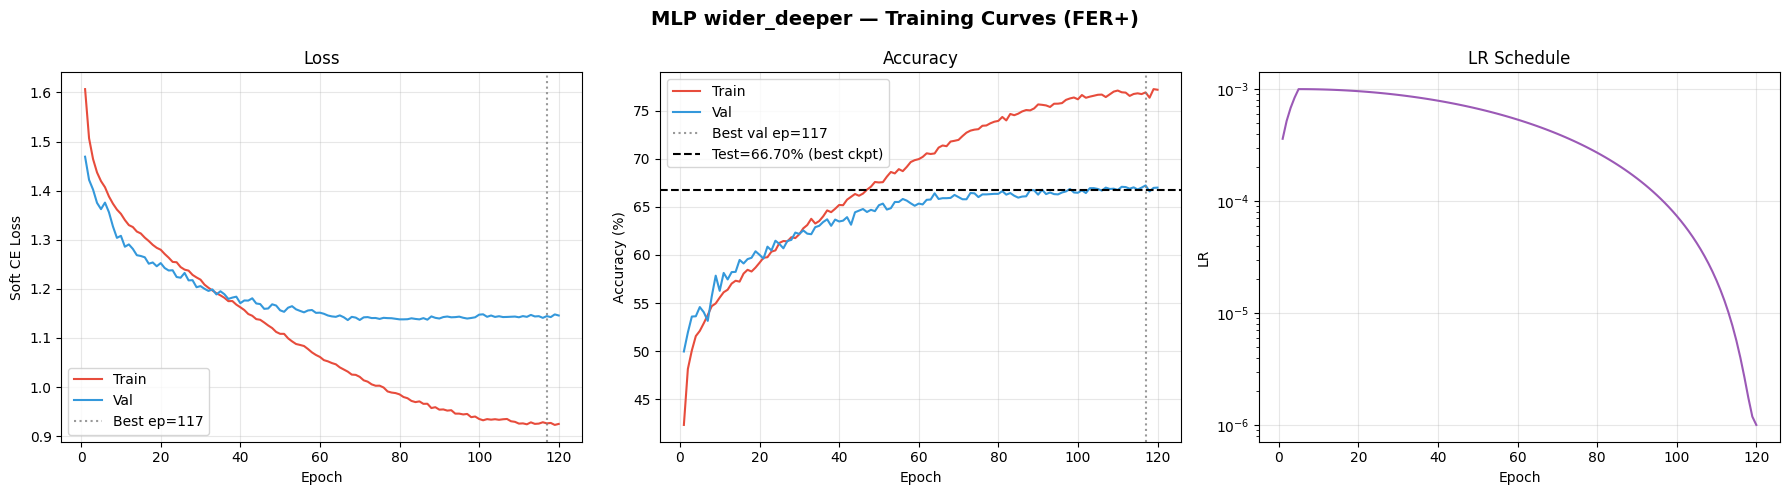

Saved: /content/ferplus_mlp_training_curves.png


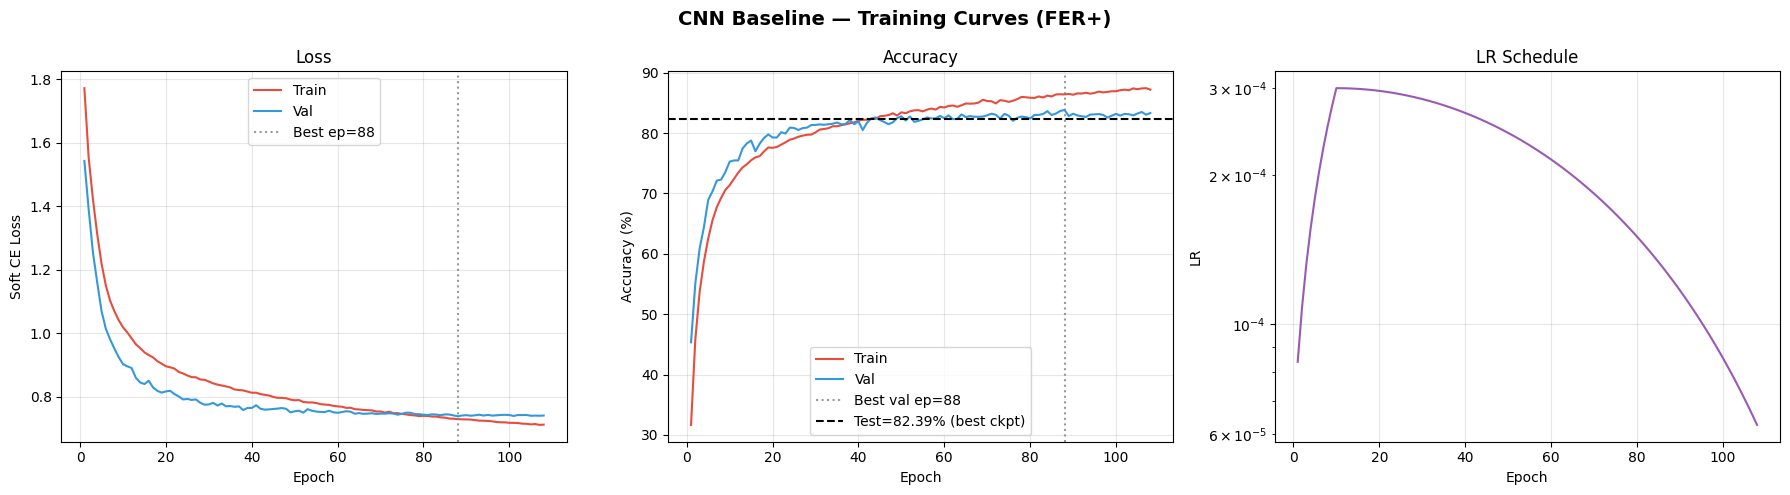

Saved: /content/ferplus_cnn_training_curves.png


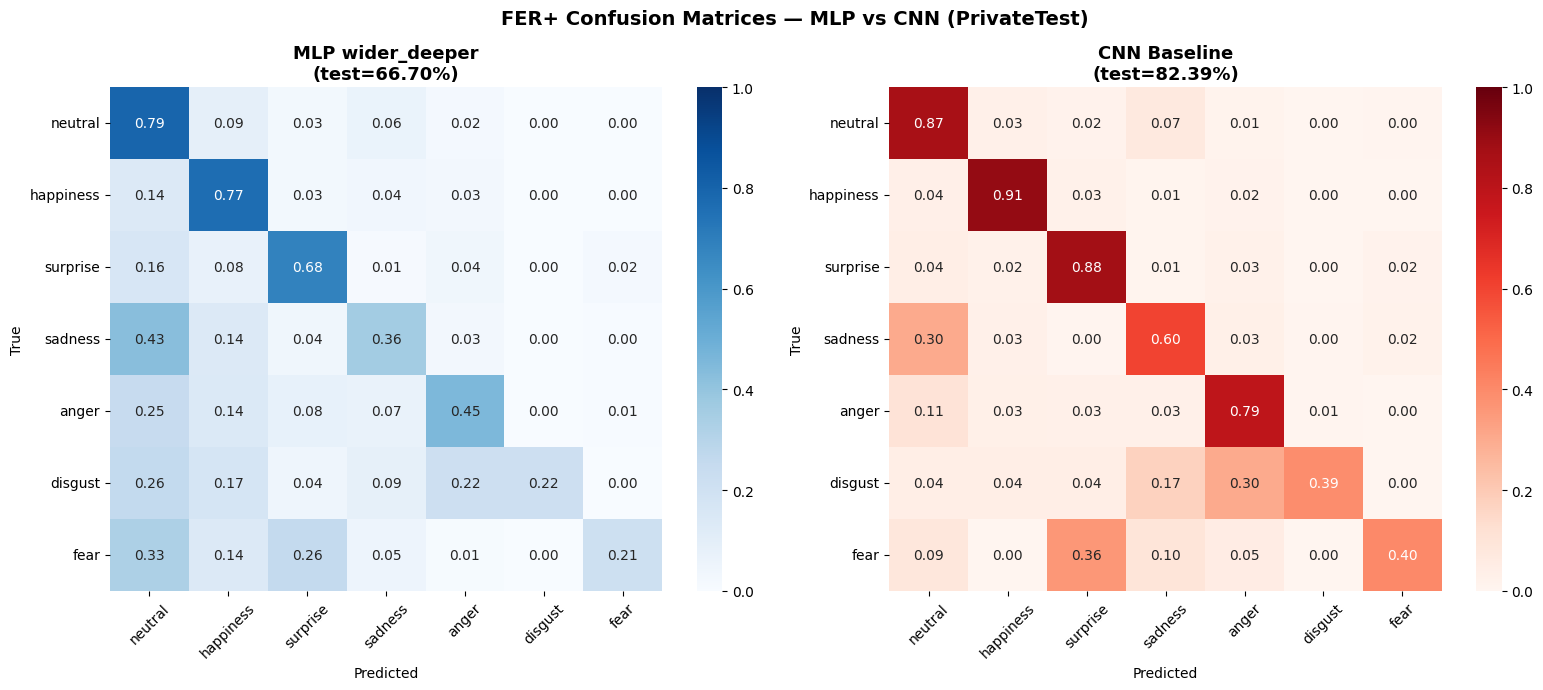

Saved: ferplus_confusion_matrices.png


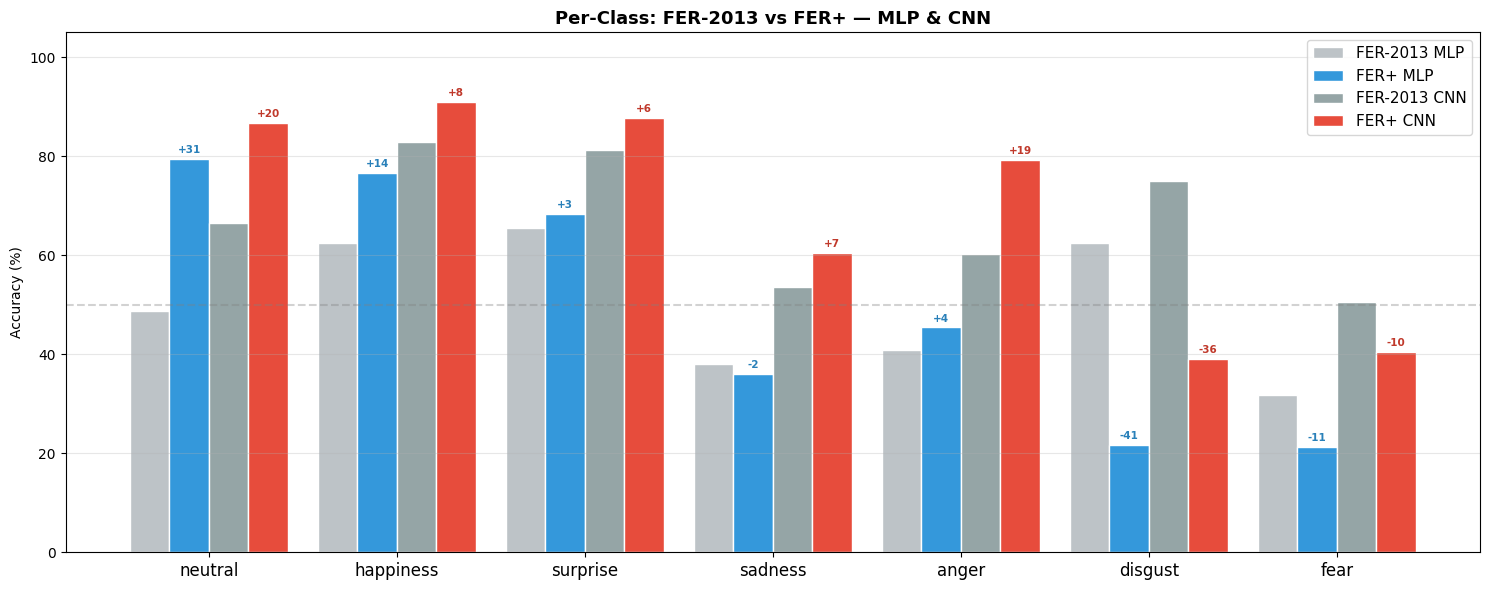

Saved: ferplus_perclass_comparison.png


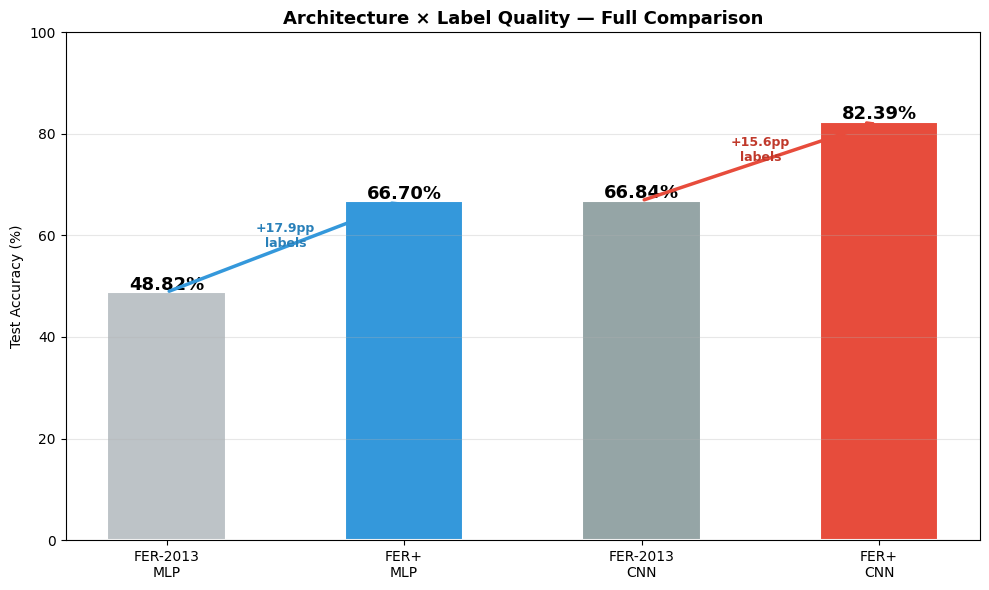

Saved: ferplus_overall_comparison.png

✅ All FER+ outputs saved to /content/
   ferplus_mlp_seed42_best.pt  |  ferplus_cnn_seed42_best.pt
   ferplus_mlp_results.json    |  ferplus_cnn_results.json
   ferplus_label_diagnostics.png
   ferplus_mlp_training_curves.png  |  ferplus_cnn_training_curves.png
   ferplus_confusion_matrices.png
   ferplus_perclass_comparison.png
   ferplus_overall_comparison.png


In [2]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  FER+ — MLP & CNN with Soft Labels                              ║
# ║  Split      : Training / PublicTest (val) / PrivateTest (test)  ║
# ║  Course     : Machine Learning, IGP-TUBS, Dr.-Ing. Maboudi      ║
# ╚══════════════════════════════════════════════════════════════════╝

# ═══════════════════════════════════════════════════════════
# CELL 1: Install + Download data
# ═══════════════════════════════════════════════════════════
import os, json, subprocess, sys
from pathlib import Path

subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "kaggle"])
kdir = os.path.expanduser("~/.kaggle")
os.makedirs(kdir, exist_ok=True)
with open(f"{kdir}/kaggle.json", "w") as f:
    json.dump({"username": "patilatharv",
               "key": "KGAT_6e476fff7b1550b8bc35669407cea260"}, f)
os.chmod(f"{kdir}/kaggle.json", 0o600)

subprocess.run([
    "kaggle", "datasets", "download",
    "-d", "deadskull7/fer2013",
    "--unzip", "-p", "/content/fer_raw"
], check=True)

print("✅ Downloads complete")
print("  FER-2013 CSV:", os.path.exists("/content/fer_raw/fer2013.csv"))
print("  FER+ CSV    :", os.path.exists("/content/FERPlus/fer2013new.csv"))

# ═══════════════════════════════════════════════════════════
# CELL 2: Reconstruct images from pixel CSV
# ═══════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
from PIL import Image

FER_CSV     = "/content/fer_raw/fer2013.csv"
FERPLUS_CSV = "/content/FERPlus/fer2013new.csv"
IMG_ROOT    = Path("/content/fer_images")

df_fer = pd.read_csv(FER_CSV)
df_fp  = pd.read_csv(FERPLUS_CSV)
df_fp.columns = df_fp.columns.str.strip()

print(f"FER-2013 rows : {len(df_fer):,}")
print(f"FER+     rows : {len(df_fp):,}")
assert len(df_fer) == len(df_fp)

for split in ['Training', 'PublicTest', 'PrivateTest']:
    (IMG_ROOT / split).mkdir(parents=True, exist_ok=True)

splits, skipped = {'Training': 0, 'PublicTest': 0, 'PrivateTest': 0}, 0
for i in range(len(df_fer)):
    split = df_fp.iloc[i]['Usage']
    fname = df_fp.iloc[i]['Image name']
    if not isinstance(fname, str):
        skipped += 1; continue
    pixels = np.array(df_fer.iloc[i]['pixels'].split(), dtype=np.uint8).reshape(48, 48)
    Image.fromarray(pixels).save(IMG_ROOT / split / fname)
    splits[split] += 1

print("\n✅ Images generated:")
for s, c in splits.items():
    print(f"  {s:15s}: {c:,}")
print(f"  Skipped: {skipped}")

# ═══════════════════════════════════════════════════════════
# CELL 3: FER+ label diagnostics + visualization
# ═══════════════════════════════════════════════════════════
import matplotlib.pyplot as plt

df = pd.read_csv(FERPLUS_CSV)
df.columns = df.columns.str.strip()
df = df.dropna()

EMOTION_COLS_8 = ['neutral','happiness','surprise','sadness',
                   'anger','disgust','fear','contempt']
EMOTIONS_7     = ['neutral','happiness','surprise','sadness',
                   'anger','disgust','fear']

vote_mat    = df[EMOTION_COLS_8].values.astype(float)
total_votes = (vote_mat.sum(axis=1)
               + df['unknown'].values.astype(float)
               + df['NF'].values.astype(float))

nf_frac      = df['NF'].values.astype(float) / np.where(total_votes > 0, total_votes, 1)
valid_nf     = nf_frac <= 0.5
c_idx        = EMOTION_COLS_8.index('contempt')
contempt_maj = np.argmax(vote_mat, axis=1) == c_idx
usable       = valid_nf & ~contempt_maj

vm7      = vote_mat.copy(); vm7[:, c_idx] = 0
row_sums = vm7[:, :7].sum(axis=1); row_sums = np.where(row_sums == 0, 1, row_sums)
soft_all = vm7[:, :7] / row_sums[:, None]
conf     = soft_all[usable].max(axis=1)
s        = soft_all[usable] + 1e-9
entropy  = -np.sum(np.where(soft_all[usable] > 0, s * np.log2(s), 0), axis=1)

print("=" * 55)
print("  FER+ DIAGNOSTIC SUMMARY")
print("=" * 55)
print(f"  Total CSV rows (after dropna)   : {len(df):,}")
print(f"  Non-face (NF > 50%)             : {(~valid_nf).sum()}")
print(f"  Contempt majority               : {(contempt_maj & valid_nf).sum()}")
print(f"  Usable 7-class                  : {usable.sum():,}")
print(f"  High-confidence (≥0.8)          : {(conf>=0.8).sum():,} ({(conf>=0.8).mean()*100:.1f}%)")
print(f"  Ambiguous (<0.5 conf)           : {(conf<0.5).sum():,} ({(conf<0.5).mean()*100:.1f}%)")
print(f"  Mean entropy                    : {entropy.mean():.3f} bits")
print(f"  Low entropy  (<1.0 bit)         : {(entropy<1.0).sum():,}")
print(f"  High entropy (>2.0 bits)        : {(entropy>2.0).sum():,}")
for split in ['Training', 'PublicTest', 'PrivateTest']:
    sm = df['Usage'].values == split
    print(f"  {split:15s}: {(usable & sm).sum():,} / {sm.sum():,} usable")
print("=" * 55)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('FER+ Label Quality Diagnostics', fontsize=14, fontweight='bold')

axes[0].hist(conf, bins=50, color='#3498db', edgecolor='white', alpha=0.85)
axes[0].axvline(0.5, color='#e74c3c', ls='--', lw=2, label='Ambiguous (<0.5)')
axes[0].axvline(0.8, color='#2ecc71', ls='--', lw=2, label='High conf (≥0.8)')
axes[0].set_xlabel('Max annotator agreement'); axes[0].set_ylabel('Count')
axes[0].set_title('Label Confidence Distribution')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].hist(entropy, bins=50, color='#e67e22', edgecolor='white', alpha=0.85)
axes[1].axvline(1.0, color='#3498db', ls='--', lw=2, label='Low entropy (<1.0)')
axes[1].axvline(2.0, color='#e74c3c', ls='--', lw=2, label='High entropy (>2.0)')
axes[1].set_xlabel('Label entropy (bits)'); axes[1].set_ylabel('Count')
axes[1].set_title('Soft Label Entropy Distribution')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/ferplus_label_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show(); print("Saved: ferplus_label_diagnostics.png")

# ═══════════════════════════════════════════════════════════
# CELL 4: Imports for training
# ═══════════════════════════════════════════════════════════
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torch.optim import AdamW
from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR
from sklearn.metrics import confusion_matrix
import seaborn as sns
import copy, time, json as _json

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

# ═══════════════════════════════════════════════════════════
# CELL 5: FERPlusDataset
# ═══════════════════════════════════════════════════════════
class FERPlusDataset(Dataset):
    EMOTIONS_8 = ['neutral','happiness','surprise','sadness',
                   'anger','disgust','fear','contempt']
    EMOTIONS_7 = ['neutral','happiness','surprise','sadness',
                   'anger','disgust','fear']

    def __init__(self, img_root, df_ferplus, split,
                 num_classes=7, exclude_nf_threshold=0.5,
                 transform=None):
        self.transform   = transform
        self.num_classes = num_classes
        self.img_root    = Path(img_root)

        df = df_ferplus[df_ferplus['Usage'] == split].copy().reset_index(drop=True)
        vote_mat    = df[self.EMOTIONS_8].values.astype(float)
        total_votes = (vote_mat.sum(axis=1)
                       + df['unknown'].values.astype(float)
                       + df['NF'].values.astype(float))

        nf_frac = df['NF'].values.astype(float) / np.where(total_votes > 0, total_votes, 1)
        valid   = nf_frac <= exclude_nf_threshold

        if num_classes == 7:
            c_idx             = self.EMOTIONS_8.index('contempt')
            contempt_majority = np.argmax(vote_mat, axis=1) == c_idx
            vote_mat[:, c_idx] = 0
            valid = valid & ~contempt_majority

        df       = df[valid].reset_index(drop=True)
        vote_mat = vote_mat[valid]

        row_sums = vote_mat[:, :num_classes].sum(axis=1, keepdims=True)
        row_sums = np.where(row_sums == 0, 1, row_sums)
        self.soft_labels = (vote_mat[:, :num_classes] / row_sums).astype(np.float32)
        self.hard_labels = np.argmax(self.soft_labels, axis=1)
        self.filenames   = df['Image name'].values
        self.split_dir   = split

        s       = self.soft_labels + 1e-9
        entropy = float(-np.sum(np.where(self.soft_labels > 0,
                                          s * np.log2(s), 0), axis=1).mean())
        print(f"[{split:12s}] {len(self.filenames):>6,} samples | "
              f"avg entropy: {entropy:.3f} bits")

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, i):
        img = Image.open(
            self.img_root / self.split_dir / self.filenames[i]
        ).convert('L')
        if self.transform: img = self.transform(img)
        return (img,
                torch.tensor(self.soft_labels[i]),
                torch.tensor(self.hard_labels[i], dtype=torch.long))

# ═══════════════════════════════════════════════════════════
# CELL 6: DataLoaders
# ═══════════════════════════════════════════════════════════
transform_train = T.Compose([
    T.RandomHorizontalFlip(), T.RandomRotation(10),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.ToTensor(), T.Normalize((0.5,), (0.5,))
])
transform_test = T.Compose([T.ToTensor(), T.Normalize((0.5,), (0.5,))])

print("Building FER+ datasets...")
train_ds = FERPlusDataset(IMG_ROOT, df, 'Training',    transform=transform_train)
val_ds   = FERPlusDataset(IMG_ROOT, df, 'PublicTest',  transform=transform_test)
test_ds  = FERPlusDataset(IMG_ROOT, df, 'PrivateTest', transform=transform_test)

print(f"\nSplit summary:")
print(f"  Train : {len(train_ds):,}  (Training split)")
print(f"  Val   : {len(val_ds):,}  (PublicTest split)")
print(f"  Test  : {len(test_ds):,}  (PrivateTest split — untouched until final eval)")

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=256, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False,
                          num_workers=2, pin_memory=True)

imgs, soft, hard = next(iter(train_loader))
print(f"\nBatch check: images={imgs.shape}  soft={soft.shape}  "
      f"sum={soft[0].sum():.3f}")

# ═══════════════════════════════════════════════════════════
# CELL 7: Loss + Architectures (identical to FER-2013)
# ═══════════════════════════════════════════════════════════
def soft_cross_entropy(logits, soft_targets):
    return -(soft_targets * F.log_softmax(logits, dim=1)).sum(dim=1).mean()


class MLP(nn.Module):
    def __init__(self, hidden=[2048,1024,512,256],
                 dropout=[0.35,0.30,0.25,0.20], num_classes=7):
        super().__init__()
        layers, in_dim = [], 48 * 48
        for h, d in zip(hidden, dropout):
            layers += [nn.Linear(in_dim, h), nn.BatchNorm1d(h),
                       nn.ReLU(), nn.Dropout(d)]
            in_dim = h
        layers.append(nn.Linear(in_dim, num_classes))
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x.view(x.size(0), -1))


class CNN(nn.Module):
    def __init__(self, channels=[32,64,128,256], fc_hidden=512,
                 dropout_conv=0.25, dropout_fc=0.50, num_classes=7):
        super().__init__()
        blocks, in_ch = [], 1
        for out_ch in channels:
            blocks += [
                nn.Conv2d(in_ch, out_ch, 3, padding=1),
                nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, 3, padding=1),
                nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
                nn.MaxPool2d(2), nn.Dropout2d(dropout_conv)
            ]
            in_ch = out_ch
        self.features   = nn.Sequential(*blocks)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(channels[-1]*3*3, fc_hidden),
            nn.BatchNorm1d(fc_hidden), nn.ReLU(inplace=True),
            nn.Dropout(dropout_fc),
            nn.Linear(fc_hidden, num_classes)
        )
    def forward(self, x): return self.classifier(self.features(x))

# ═══════════════════════════════════════════════════════════
# CELL 8: Generic training + evaluation functions
# Test is NEVER touched inside train_ferplus
# ═══════════════════════════════════════════════════════════
SEED = 42

def evaluate_ferplus(model, loader, device):
    """Val evaluation only — loss + accuracy on hard labels."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, soft, hard in loader:
            imgs, soft, hard = imgs.to(device), soft.to(device), hard.to(device)
            logits      = model(imgs)
            total_loss += soft_cross_entropy(logits, soft).item() * imgs.size(0)
            correct    += (logits.argmax(1) == hard).sum().item()
            total      += hard.size(0)
    return total_loss / total, correct / total


def train_ferplus(model, train_loader, val_loader,
                  lr, wd, max_epochs, warmup_epochs, patience, device, name):
    """
    Trains on train_loader, validates on val_loader only.
    Test loader is NOT passed in — never touched during training.
    """
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=wd)
    warmup_s  = LinearLR(optimizer, start_factor=0.2, end_factor=1.0,
                          total_iters=warmup_epochs)
    cosine_s  = CosineAnnealingLR(optimizer, T_max=max_epochs - warmup_epochs,
                                   eta_min=1e-6)
    scheduler = SequentialLR(optimizer, [warmup_s, cosine_s],
                              milestones=[warmup_epochs])

    # History: train and val ONLY
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc':  [], 'val_acc':  [],
        'lr': []
    }
    best_val_acc, best_weights, patience_ctr, best_epoch = 0.0, None, 0, 0

    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\n{name} | Parameters: {n_params:,}")
    print(f"Config: lr={lr}  wd={wd}  max_ep={max_epochs}  "
          f"warmup={warmup_epochs}  patience={patience}")
    print(f"\n{'Ep':>4}  {'LR':>10}  {'Tr Loss':>8}  {'Tr Acc':>7}  "
          f"{'Va Loss':>8}  {'Va Acc':>7}")
    print("─" * 62)

    t0 = time.time()
    for epoch in range(1, max_epochs + 1):

        # ── Train ──────────────────────────────────────────
        model.train()
        tr_loss, tr_correct, tr_total = 0.0, 0, 0
        for imgs, soft, hard in train_loader:
            imgs, soft, hard = imgs.to(device), soft.to(device), hard.to(device)
            optimizer.zero_grad()
            logits = model(imgs)
            loss   = soft_cross_entropy(logits, soft)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            tr_loss    += loss.item() * imgs.size(0)
            tr_correct += (logits.argmax(1) == hard).sum().item()
            tr_total   += hard.size(0)

        scheduler.step()
        tr_loss /= tr_total
        tr_acc   = tr_correct / tr_total

        # ── Val only ───────────────────────────────────────
        va_loss, va_acc = evaluate_ferplus(model, val_loader, device)
        cur_lr = scheduler.get_last_lr()[0]

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(va_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(va_acc)
        history['lr'].append(cur_lr)

        star = ""
        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_weights = copy.deepcopy(model.state_dict())
            patience_ctr = 0; best_epoch = epoch; star = " ★"
        else:
            patience_ctr += 1

        print(f"{epoch:4d}  {cur_lr:10.2e}  {tr_loss:8.4f}  {tr_acc*100:6.2f}%  "
              f"{va_loss:8.4f}  {va_acc*100:6.2f}%{star}")

        if patience_ctr >= patience:
            print(f"\n⏹  Early stop @ ep {epoch}  "
                  f"(best val {best_val_acc*100:.2f}% @ ep {best_epoch})")
            break

    elapsed = (time.time() - t0) / 60
    print(f"\n✅ Training done in {elapsed:.1f} min")

    # Load best checkpoint — test is evaluated AFTER this in a separate cell
    model.load_state_dict(best_weights)
    return model, history, best_val_acc, best_epoch


def evaluate_final(model, test_loader, device, label_names):
    """Called once after training, on best checkpoint. First and only test touch."""
    print("\n" + "═"*50)
    print("FINAL TEST EVALUATION — best checkpoint only")
    print("═"*50)
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, soft, hard in test_loader:
            preds = model(imgs.to(device)).argmax(1).cpu()
            all_preds.append(preds); all_labels.append(hard)
    preds  = torch.cat(all_preds).numpy()
    labels = torch.cat(all_labels).numpy()
    acc    = (preds == labels).mean()

    print(f"\n  Test Accuracy : {acc*100:.2f}%")
    print(f"\n  {'Class':12s}  {'N':>5}  {'Acc':>6}")
    print("─" * 35)
    per_class = []
    for i, name in enumerate(label_names):
        mask = labels == i
        a    = (preds[mask] == i).mean() if mask.sum() > 0 else 0.0
        per_class.append(a)
        flag = "⚠️ " if a < 0.40 else "✅"
        print(f"  {name:12s}: {mask.sum():5d}  {a*100:5.1f}%  "
              f"{flag} {'█'*int(a*25)}")
    return acc, preds, labels, per_class

# ═══════════════════════════════════════════════════════════
# CELL 9: Train MLP on FER+
# Note: test_loader NOT passed to train_ferplus
# ═══════════════════════════════════════════════════════════
torch.manual_seed(SEED)
mlp_model = MLP().to(DEVICE)
mlp_model, mlp_history, mlp_best_val, mlp_best_ep = train_ferplus(
    mlp_model, train_loader, val_loader,
    lr=1e-3, wd=5e-5, max_epochs=120, warmup_epochs=5,
    patience=20, device=DEVICE, name="MLP wider_deeper (FER+)"
)
torch.save(mlp_model.state_dict(), "/content/ferplus_mlp_seed42_best.pt")
print(f"💾 Saved → ferplus_mlp_seed42_best.pt  "
      f"(best val {mlp_best_val*100:.2f}% @ ep {mlp_best_ep})")

# ═══════════════════════════════════════════════════════════
# CELL 10: Evaluate MLP — once, on best checkpoint
# ═══════════════════════════════════════════════════════════
mlp_test_acc, mlp_preds, mlp_labels, mlp_per_class = evaluate_final(
    mlp_model, test_loader, DEVICE, FERPlusDataset.EMOTIONS_7
)

print(f"\n  Best val epoch : {mlp_best_ep}")
print(f"  Best val acc   : {mlp_best_val*100:.2f}%")
print(f"  Test acc       : {mlp_test_acc*100:.2f}%")
print(f"  FER-2013 MLP   : ~49.3%  →  label gain: "
      f"{(mlp_test_acc-0.493)*100:+.1f}pp")

with open("/content/ferplus_mlp_results.json", "w") as f:
    _json.dump({
        "model": "FERPlus_MLP_wider_deeper", "seed": SEED,
        "split": "Training/PublicTest/PrivateTest",
        "best_val_acc":   float(mlp_best_val),
        "best_epoch":     mlp_best_ep,
        "test_acc_final": float(mlp_test_acc),
        "per_class_acc":  {FERPlusDataset.EMOTIONS_7[i]: float(mlp_per_class[i])
                           for i in range(7)},
        "history": mlp_history
    }, f, indent=2)
print("💾 Saved → ferplus_mlp_results.json")

# ═══════════════════════════════════════════════════════════
# CELL 11: Train CNN on FER+
# Note: test_loader NOT passed to train_ferplus
# ═══════════════════════════════════════════════════════════
torch.manual_seed(SEED)
cnn_model = CNN().to(DEVICE)
cnn_model, cnn_history, cnn_best_val, cnn_best_ep = train_ferplus(
    cnn_model, train_loader, val_loader,
    lr=3e-4, wd=1e-4, max_epochs=150, warmup_epochs=10,
    patience=20, device=DEVICE, name="CNN baseline (FER+)"
)
torch.save(cnn_model.state_dict(), "/content/ferplus_cnn_seed42_best.pt")
print(f"💾 Saved → ferplus_cnn_seed42_best.pt  "
      f"(best val {cnn_best_val*100:.2f}% @ ep {cnn_best_ep})")

# ═══════════════════════════════════════════════════════════
# CELL 12: Evaluate CNN — once, on best checkpoint
# ═══════════════════════════════════════════════════════════
cnn_test_acc, cnn_preds, cnn_labels, cnn_per_class = evaluate_final(
    cnn_model, test_loader, DEVICE, FERPlusDataset.EMOTIONS_7
)

print(f"\n  Best val epoch : {cnn_best_ep}")
print(f"  Best val acc   : {cnn_best_val*100:.2f}%")
print(f"  Test acc       : {cnn_test_acc*100:.2f}%")
print(f"  FER-2013 CNN   : ~62.0%  →  label gain: "
      f"{(cnn_test_acc-0.620)*100:+.1f}pp")

print(f"\n{'='*60}")
print(f"  FULL COMPARISON SUMMARY")
print(f"{'='*60}")
print(f"  FER-2013  MLP  hard labels :  ~49.3%  (3-seed mean)")
print(f"  FER-2013  CNN  hard labels :  ~62.0%  (3-seed mean)")
print(f"  FER+      MLP  soft labels :  {mlp_test_acc*100:.2f}%  (seed=42)")
print(f"  FER+      CNN  soft labels :  {cnn_test_acc*100:.2f}%  (seed=42)")
print(f"{'='*60}")
print(f"  Architecture gap  FER-2013 : +12.7pp")
print(f"  Label gain MLP             : {(mlp_test_acc-0.493)*100:+.1f}pp")
print(f"  Label gain CNN             : {(cnn_test_acc-0.620)*100:+.1f}pp")
print(f"  Architecture gap  FER+     : {(cnn_test_acc-mlp_test_acc)*100:+.1f}pp")
print(f"{'='*60}")

with open("/content/ferplus_cnn_results.json", "w") as f:
    _json.dump({
        "model": "FERPlus_CNN_baseline", "seed": SEED,
        "split": "Training/PublicTest/PrivateTest",
        "best_val_acc":   float(cnn_best_val),
        "best_epoch":     cnn_best_ep,
        "test_acc_final": float(cnn_test_acc),
        "per_class_acc":  {FERPlusDataset.EMOTIONS_7[i]: float(cnn_per_class[i])
                           for i in range(7)},
        "history": cnn_history
    }, f, indent=2)
print("💾 Saved → ferplus_cnn_results.json")

# ═══════════════════════════════════════════════════════════
# CELL 13: Visualizations
# Training curves: train/val only — test as single horizontal line
# Val-vs-test per epoch plot removed (no per-epoch test data)
# ═══════════════════════════════════════════════════════════
EMOTIONS = FERPlusDataset.EMOTIONS_7

def plot_training_curves(history, best_epoch, test_acc, title, fname):
    """
    Train and val curves per epoch.
    Test appears only as a single dashed horizontal line at final value.
    """
    ep_axis = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    # Loss — train and val only
    axes[0].plot(ep_axis, history['train_loss'], color='#e74c3c', label='Train', lw=1.5)
    axes[0].plot(ep_axis, history['val_loss'],   color='#3498db', label='Val',   lw=1.5)
    axes[0].axvline(best_epoch, color='gray', ls=':', alpha=0.8,
                    label=f'Best ep={best_epoch}')
    axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Soft CE Loss')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    # Accuracy — train and val per epoch, test as single line
    axes[1].plot(ep_axis, [a*100 for a in history['train_acc']],
                 color='#e74c3c', label='Train', lw=1.5)
    axes[1].plot(ep_axis, [a*100 for a in history['val_acc']],
                 color='#3498db', label='Val', lw=1.5)
    axes[1].axvline(best_epoch, color='gray', ls=':', alpha=0.8,
                    label=f'Best val ep={best_epoch}')
    axes[1].axhline(test_acc*100, color='black', ls='--', lw=1.5,
                    label=f'Test={test_acc*100:.2f}% (best ckpt)')
    axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    # LR schedule
    axes[2].plot(ep_axis, history['lr'], color='#9b59b6', lw=1.5)
    axes[2].set_title('LR Schedule'); axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('LR'); axes[2].set_yscale('log'); axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show(); print(f"Saved: {fname}")


plot_training_curves(mlp_history, mlp_best_ep, mlp_test_acc,
                     'MLP wider_deeper — Training Curves (FER+)',
                     '/content/ferplus_mlp_training_curves.png')

plot_training_curves(cnn_history, cnn_best_ep, cnn_test_acc,
                     'CNN Baseline — Training Curves (FER+)',
                     '/content/ferplus_cnn_training_curves.png')

# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('FER+ Confusion Matrices — MLP vs CNN (PrivateTest)',
             fontsize=14, fontweight='bold')
for ax, p, l, title, cmap in [
    (axes[0], mlp_preds, mlp_labels,
     f'MLP wider_deeper\n(test={mlp_test_acc*100:.2f}%)', 'Blues'),
    (axes[1], cnn_preds, cnn_labels,
     f'CNN Baseline\n(test={cnn_test_acc*100:.2f}%)', 'Reds'),
]:
    cm = confusion_matrix(l, p, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap=cmap,
                xticklabels=EMOTIONS, yticklabels=EMOTIONS,
                ax=ax, vmin=0, vmax=1, annot_kws={'size': 10})
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=45); ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('/content/ferplus_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show(); print("Saved: ferplus_confusion_matrices.png")

# Per-class 4-bar comparison
# Updated from new runs — order: neutral, happiness, surprise, sadness, anger, disgust, fear
fer13_mlp = [48.7, 62.4, 65.5, 38.0, 40.9, 62.5, 31.8]  # MLP FER-2013 seed=42
fer13_cnn = [66.4, 82.9, 81.2, 53.5, 60.2, 75.0, 50.6]  # CNN FER-2013 seed=42
x, width  = np.arange(7), 0.21

fig, ax = plt.subplots(figsize=(15, 6))
ax.bar(x-1.5*width, fer13_mlp,
       width, label='FER-2013 MLP', color='#bdc3c7', edgecolor='white')
ax.bar(x-0.5*width, [a*100 for a in mlp_per_class],
       width, label='FER+ MLP',     color='#3498db', edgecolor='white')
ax.bar(x+0.5*width, fer13_cnn,
       width, label='FER-2013 CNN', color='#95a5a6', edgecolor='white')
ax.bar(x+1.5*width, [a*100 for a in cnn_per_class],
       width, label='FER+ CNN',     color='#e74c3c', edgecolor='white')
for i in range(7):
    ax.text(x[i]-0.5*width, mlp_per_class[i]*100+1.2,
            f'{mlp_per_class[i]*100-fer13_mlp[i]:+.0f}',
            ha='center', fontsize=7.5, color='#2980b9', fontweight='bold')
    ax.text(x[i]+1.5*width, cnn_per_class[i]*100+1.2,
            f'{cnn_per_class[i]*100-fer13_cnn[i]:+.0f}',
            ha='center', fontsize=7.5, color='#c0392b', fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(EMOTIONS, fontsize=12)
ax.set_ylabel('Accuracy (%)'); ax.set_ylim(0, 105)
ax.set_title('Per-Class: FER-2013 vs FER+ — MLP & CNN',
             fontsize=13, fontweight='bold')
ax.axhline(50, color='gray', ls='--', alpha=0.35)
ax.legend(fontsize=11); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/ferplus_perclass_comparison.png', dpi=150, bbox_inches='tight')
plt.show(); print("Saved: ferplus_perclass_comparison.png")

# 4-bar headline chart — updated baselines: MLP 48.82%, CNN 66.84%
fig, ax = plt.subplots(figsize=(10, 6))
experiments = ['FER-2013\nMLP', 'FER+\nMLP', 'FER-2013\nCNN', 'FER+\nCNN']
accs        = [48.82, mlp_test_acc*100, 66.84, cnn_test_acc*100]
colors      = ['#bdc3c7', '#3498db', '#95a5a6', '#e74c3c']
bars        = ax.bar(experiments, accs, color=colors,
                     width=0.5, edgecolor='white', lw=1.5)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{acc:.2f}%', ha='center', fontsize=13, fontweight='bold')
ax.annotate('', xy=(1, mlp_test_acc*100), xytext=(0, 48.82),
            arrowprops=dict(arrowstyle='->', color='#3498db', lw=2.5))
ax.text(0.5, (48.82+mlp_test_acc*100)/2,
        f'+{mlp_test_acc*100-48.82:.1f}pp\nlabels',
        ha='center', fontsize=9, color='#2980b9', fontweight='bold')
ax.annotate('', xy=(3, cnn_test_acc*100), xytext=(2, 66.84),
            arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=2.5))
ax.text(2.5, (66.84+cnn_test_acc*100)/2,
        f'+{cnn_test_acc*100-66.84:.1f}pp\nlabels',
        ha='center', fontsize=9, color='#c0392b', fontweight='bold')
ax.set_ylabel('Test Accuracy (%)'); ax.set_ylim(0, 100)
ax.set_title('Architecture × Label Quality — Full Comparison',
             fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/ferplus_overall_comparison.png', dpi=150, bbox_inches='tight')
plt.show(); print("Saved: ferplus_overall_comparison.png")

print("\n✅ All FER+ outputs saved to /content/")
print("   ferplus_mlp_seed42_best.pt  |  ferplus_cnn_seed42_best.pt")
print("   ferplus_mlp_results.json    |  ferplus_cnn_results.json")
print("   ferplus_label_diagnostics.png")
print("   ferplus_mlp_training_curves.png  |  ferplus_cnn_training_curves.png")
print("   ferplus_confusion_matrices.png")
print("   ferplus_perclass_comparison.png")
print("   ferplus_overall_comparison.png")